# Load Data

Link to dataset: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Paths
DRIVE_ZIP = '/content/drive/MyDrive/WasteDataset.zip'
DATASET_PATH = '/content/dataset/'
DATASET_ROOT = '/content/dataset/images/images'   # raw source classes
SPLIT_ROOT = '/content/dataset_split'            # output after restructure

os.makedirs(DATASET_PATH, exist_ok=True)

Mounted at /content/drive


In [2]:
# Copy zip from Drive and extract
!cp "{DRIVE_ZIP}" "{DATASET_PATH}"
%cd "{DATASET_PATH}"
!unzip -qq "{os.path.basename(DRIVE_ZIP)}"
%cd /content

/content/dataset
/content


### Data loading and preprocessing functions

In [3]:
import os
import shutil
import random
import hashlib
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from collections import defaultdict


# Filesystem
def explore_dataset_folder(root_path, max_files=3):
    """Recursively prints folder structure, capping files shown per folder."""
    for root, dirs, files in os.walk(root_path):
        level = root.replace(root_path, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}[{os.path.basename(root)}/]")
        sub_indent = ' ' * 4 * (level + 1)
        for f in files[:max_files]:
            print(f"{sub_indent}{f}")
        if len(files) > max_files:
            print(f"{sub_indent}... and {len(files) - max_files} more files")


# Hashing
def hash_image(path):
    """Returns an MD5 hash of the image pixel content, normalized to RGB."""
    with Image.open(path) as img:
        return hashlib.md5(img.convert("RGB").tobytes()).hexdigest()


# Raw dataset duplicate check (before splitting)
def check_raw_duplicates(src_root):
    """
    Checks for duplicate images within each class across its subfolders
    (e.g. default/ vs real_world/) in the original unsplit dataset.
    Returns a dict of {class_name: [(path_a, path_b), ...]} for all duplicates found.
    """
    print("Hashing raw dataset...\n")
    all_duplicates = {}
    total_dupes = 0

    for class_name in sorted(os.listdir(src_root)):
        class_path = os.path.join(src_root, class_name)
        if not os.path.isdir(class_path):
            continue

        hash_to_path = {}
        dupes = []

        for subfolder in os.listdir(class_path):
            subfolder_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                fpath = os.path.join(subfolder_path, fname)
                try:
                    h = hash_image(fpath)
                    if h in hash_to_path:
                        dupes.append((hash_to_path[h], fpath))
                    else:
                        hash_to_path[h] = fpath
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")

        if dupes:
            all_duplicates[class_name] = dupes
            total_dupes += len(dupes)
            print(f"  [{class_name}]: {len(dupes)} duplicate(s)")

    print(f"\n=== Summary ===")
    if total_dupes == 0:
        print("No duplicates found in raw dataset.")
    else:
        print(f"Found {total_dupes} duplicate image(s) across {len(all_duplicates)} class(es).")
        print("These will be removed during restructure_dataset().")

    return all_duplicates


def plot_raw_duplicates(all_duplicates, num_examples=5):
    """
    Plots duplicate image pairs found in the raw dataset side by side.

    Args:
        all_duplicates: dict returned by check_raw_duplicates()
        num_examples:   max number of pairs to plot
    """
    pairs = []
    for class_name, dupes in all_duplicates.items():
        for path_a, path_b in dupes:
            pairs.append((class_name, path_a, path_b))
            if len(pairs) >= num_examples:
                break
        if len(pairs) >= num_examples:
            break

    if not pairs:
        print("No duplicates to plot.")
        return

    fig, axes = plt.subplots(len(pairs), 2, figsize=(6, 3 * len(pairs)))
    fig.suptitle("Duplicate Images in Raw Dataset", fontsize=14, fontweight="bold", y=1.01)

    if len(pairs) == 1:
        axes = [axes]

    for i, (class_name, path_a, path_b) in enumerate(pairs):
        for ax, path, subfolder_label in zip(
            axes[i],
            [path_a, path_b],
            [os.path.basename(os.path.dirname(path_a)),
             os.path.basename(os.path.dirname(path_b))]
        ):
            ax.imshow(Image.open(path).convert("RGB"))
            ax.axis("off")
            ax.set_title(
                f"[{class_name}]\n{subfolder_label}\n{os.path.basename(path)}",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()


# Restructure and deduplicate dataset
def restructure_dataset(src_root, dst_root, train=0.8, val=0.1, test=0.1, seed=42):
    """
    Converts:
        src_root/{class_name}/{subfolder}/images...
    Into:
        dst_root/train/{class_name}/images...
        dst_root/val/{class_name}/images...
        dst_root/test/{class_name}/images...

    Deduplicates globally across all classes before splitting, so identical
    images (even across classes) always land in the same split.
    """
    assert abs(train + val + test - 1.0) < 1e-6, "Splits must sum to 1.0"
    random.seed(seed)

    print("Hashing all images for global deduplication...")
    global_seen   = {}  # {hash: (class_name, path)}
    class_buckets = defaultdict(list)  # {class_name: [unique paths]}

    for class_name in sorted(os.listdir(src_root)):
        class_path = os.path.join(src_root, class_name)
        if not os.path.isdir(class_path):
            continue
        for subfolder in os.listdir(class_path):
            subfolder_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                fpath = os.path.join(subfolder_path, fname)
                try:
                    h = hash_image(fpath)
                    if h in global_seen:
                        continue  # skip global duplicate
                    global_seen[h] = (class_name, fpath)
                    class_buckets[class_name].append(fpath)
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")

    print(f"Found {len(global_seen)} unique images across {len(class_buckets)} classes.\n")

    for class_name, images in class_buckets.items():
        random.shuffle(images)
        n       = len(images)
        n_train = int(n * train)
        n_val   = int(n * val)

        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:]
        }

        counts = {}
        for split_name, files in splits.items():
            out_dir = os.path.join(dst_root, split_name, class_name)
            os.makedirs(out_dir, exist_ok=True)
            for src_path in files:
                subfolder = os.path.basename(os.path.dirname(src_path))
                fname     = f"{subfolder}_{os.path.basename(src_path)}"
                shutil.copy(src_path, os.path.join(out_dir, fname))
            counts[split_name] = len(files)

        print(f"  {class_name}: {counts['train']} train | {counts['val']} val | {counts['test']} test  ({n} unique)")


# Leakage check on split dataset
def check_leakage_by_hash(dataset_root):
    """
    Checks for data leakage across train/val/test splits by comparing MD5
    hashes. Catches duplicates even if they have different filenames.
    """
    splits = ["train", "val", "test"]
    print("Hashing split dataset...\n")

    split_hashes = {}
    for split in splits:
        split_hashes[split] = {}
        split_dir = os.path.join(dataset_root, split)
        for class_name in sorted(os.listdir(split_dir)):
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                try:
                    h = hash_image(fpath)
                    split_hashes[split][h] = (class_name, fname)
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")
        print(f"  {split}: {len(split_hashes[split])} unique images")

    pairs         = [("train", "val"), ("train", "test"), ("val", "test")]
    leakage_found = False

    for split_a, split_b in pairs:
        overlap = set(split_hashes[split_a]) & set(split_hashes[split_b])
        print(f"\n--- {split_a} vs {split_b} ---")
        if not overlap:
            print("  No leakage found.")
        else:
            leakage_found = True
            print(f"  WARNING: {len(overlap)} duplicate(s) found:")
            for h in sorted(overlap)[:5]:
                ca, fa = split_hashes[split_a][h]
                cb, fb = split_hashes[split_b][h]
                print(f"    [{ca}] {fa}  ==  [{cb}] {fb}")
            if len(overlap) > 5:
                print(f"    ... and {len(overlap) - 5} more")

    print("\n=== Summary ===")
    if leakage_found:
        print("WARNING: Leakage detected. Re-run restructure_dataset() to fix.")
    else:
        print("No data leakage detected. Splits are clean.")


# Dataloader helpers
def count_images(dataset):
    """Counts total images in a batched tf.data.Dataset."""
    count = 0
    for images, _ in dataset:
        count += images.shape[0]
    return count

### Explore raw dataset structure

In [4]:
explore_dataset_folder(DATASET_ROOT, max_files=3)

[images/]
    [plastic_soda_bottles/]
        [default/]
            Image_26.png
            Image_113.png
            Image_224.png
            ... and 247 more files
        [real_world/]
            Image_26.png
            Image_113.png
            Image_224.png
            ... and 247 more files
    [plastic_straws/]
        [default/]
            Image_26.png
            Image_113.png
            Image_224.png
            ... and 247 more files
        [real_world/]
            Image_26.png
            Image_113.png
            Image_224.png
            ... and 247 more files
    [cardboard_packaging/]
        [default/]
            Image_26.png
            Image_113.png
            Image_224.png
            ... and 247 more files
        [real_world/]
            Image_26.png
            Image_113.png
            Image_224.png
            ... and 247 more files
    [paper_cups/]
        [default/]
            Image_26.png
            Image_113.png
            Image_224.png
    

### Check Raw Dataset for Duplicates

Before splitting, check for duplicate images between the `default/` and `real_world/`
subfolders within each class. These would cause data leakage if not removed before splitting.

In [5]:
raw_duplicates = check_raw_duplicates(DATASET_ROOT)

Hashing raw dataset...

  [aerosol_cans]: 147 duplicate(s)
  [aluminum_food_cans]: 118 duplicate(s)
  [aluminum_soda_cans]: 110 duplicate(s)
  [cardboard_boxes]: 102 duplicate(s)
  [cardboard_packaging]: 124 duplicate(s)
  [clothing]: 9 duplicate(s)
  [coffee_grounds]: 133 duplicate(s)
  [disposable_plastic_cutlery]: 139 duplicate(s)
  [eggshells]: 94 duplicate(s)
  [food_waste]: 201 duplicate(s)
  [glass_beverage_bottles]: 168 duplicate(s)
  [glass_cosmetic_containers]: 161 duplicate(s)
  [glass_food_jars]: 137 duplicate(s)
  [magazines]: 54 duplicate(s)
  [newspaper]: 14 duplicate(s)
  [office_paper]: 64 duplicate(s)
  [paper_cups]: 94 duplicate(s)
  [plastic_cup_lids]: 134 duplicate(s)
  [plastic_detergent_bottles]: 146 duplicate(s)
  [plastic_food_containers]: 153 duplicate(s)
  [plastic_shopping_bags]: 127 duplicate(s)
  [plastic_soda_bottles]: 154 duplicate(s)
  [plastic_straws]: 96 duplicate(s)
  [plastic_trash_bags]: 134 duplicate(s)
  [plastic_water_bottles]: 96 duplicate(s)
 

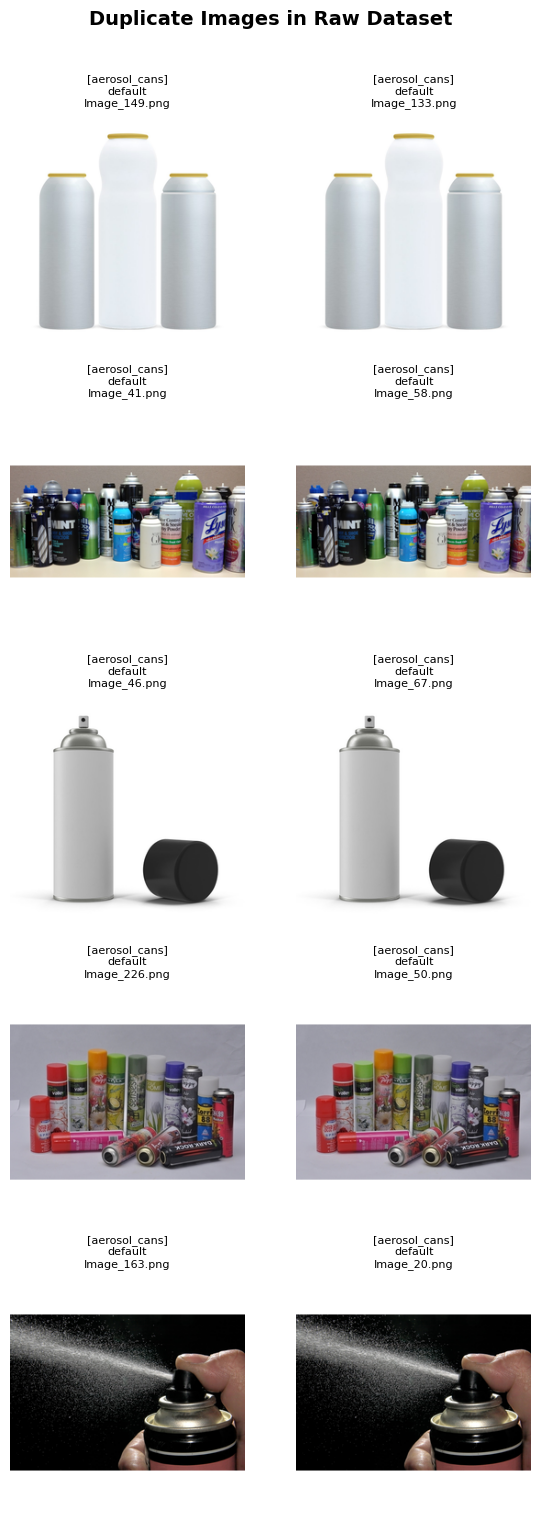

In [6]:
plot_raw_duplicates(raw_duplicates, num_examples=5)

### Restructure Dataset

Splits the dataset into `train/`, `val/`, and `test/` folders while globally
deduplicating by image hash so no identical image appears in more than one split.

In [7]:
shutil.rmtree(SPLIT_ROOT, ignore_errors=True)  # wipe any previous split
restructure_dataset(
    src_root=DATASET_ROOT,
    dst_root=SPLIT_ROOT,
    train=0.8,
    val=0.1,
    test=0.1,
    seed=42
)

Hashing all images for global deduplication...
Found 11263 unique images across 30 classes.

  aerosol_cans: 282 train | 35 val | 36 test  (353 unique)
  aluminum_food_cans: 305 train | 38 val | 39 test  (382 unique)
  aluminum_soda_cans: 304 train | 38 val | 39 test  (381 unique)
  cardboard_boxes: 318 train | 39 val | 41 test  (398 unique)
  cardboard_packaging: 212 train | 26 val | 27 test  (265 unique)
  clothing: 392 train | 49 val | 50 test  (491 unique)
  coffee_grounds: 293 train | 36 val | 38 test  (367 unique)
  disposable_plastic_cutlery: 288 train | 36 val | 37 test  (361 unique)
  eggshells: 324 train | 40 val | 42 test  (406 unique)
  food_waste: 239 train | 29 val | 31 test  (299 unique)
  glass_beverage_bottles: 265 train | 33 val | 34 test  (332 unique)
  glass_cosmetic_containers: 271 train | 33 val | 35 test  (339 unique)
  glass_food_jars: 289 train | 36 val | 37 test  (362 unique)
  magazines: 356 train | 44 val | 46 test  (446 unique)
  newspaper: 388 train | 48 v

### Verify No Data Leakage in Split Dataset

In [8]:
check_leakage_by_hash(SPLIT_ROOT)

Hashing split dataset...

  train: 8995 unique images
  val: 1113 unique images
  test: 1155 unique images

--- train vs val ---
  No leakage found.

--- train vs test ---
  No leakage found.

--- val vs test ---
  No leakage found.

=== Summary ===
No data leakage detected. Splits are clean.


### Create dataloaders

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load train first to extract class_names before prefetch wraps it
_train_base = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_ROOT, "train"),
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
)

# Get class names
class_names  = _train_base.class_names
idx_to_class = {i: name for i, name in enumerate(class_names)}

# Make the dataloaders
train_dataset = _train_base.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_ROOT, "val"),
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_ROOT, "test"),
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
).prefetch(tf.data.AUTOTUNE)

train_count = count_images(train_dataset)
val_count   = count_images(val_dataset)
test_count  = count_images(test_dataset)
total = train_count + val_count + test_count

print(f"Num classes:   {len(class_names)}")
print(f"Classes:       {class_names}")
print(f"Train images:  {train_count}")
print(f"Val images:    {val_count}")
print(f"Test images:   {test_count}")
print (f"Total images: {total}")

Found 8995 files belonging to 30 classes.
Found 1113 files belonging to 30 classes.
Found 1155 files belonging to 30 classes.
Num classes:   30
Classes:       ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']
Train images:  8995
Val images:    1113
Test images:   1155
Total images: 11263


## Visualize the data

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, class_names=None):
    plt.figure(figsize=(8, 8))

    # Take one batch only
    for images, labels in dataset.take(1):
        for i in range(8):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            if class_names is not None:
                label_idx = np.argmax(labels[i])
                plt.title(class_names[label_idx])

            plt.axis("off")

    plt.tight_layout()
    plt.show()

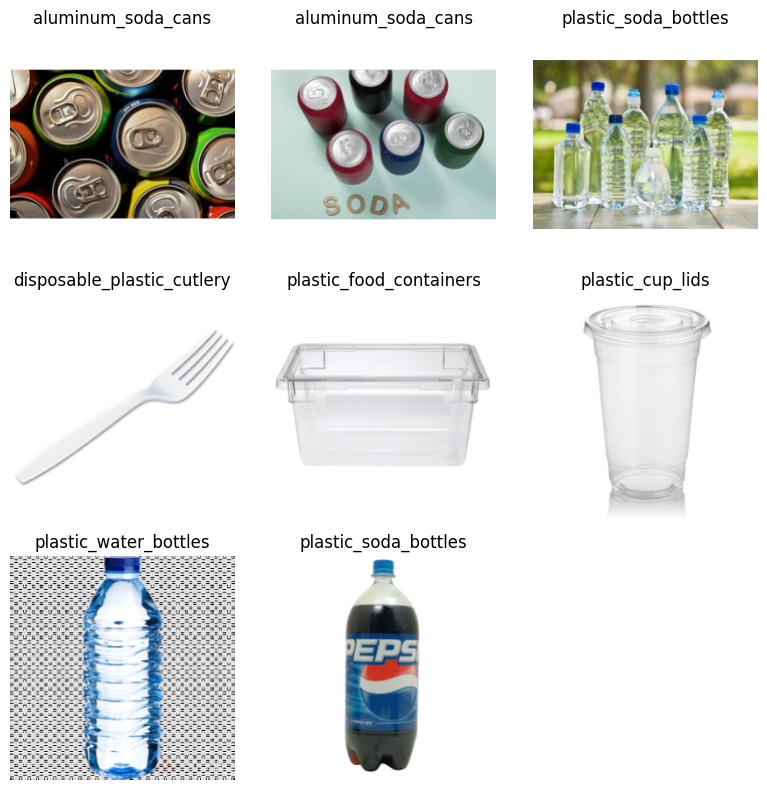

In [11]:
show_images(train_dataset, class_names)

# Training

## Setup functions for training and eval

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    ConfusionMatrixDisplay
)

def plot_loss_acc_training(history):
    """
    Plots training vs. validation accuracy and loss over epochs.

    Args:
        history: Keras History object returned by model.fit()
    """
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "bo", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()


def plot_predictions_grid(model, dataset, class_names, num_images=9):
    """
    Displays a grid of images with the model's predicted label and confidence.
    Titles are green for correct predictions and red for incorrect ones.

    Args:
        model:       Trained Keras/TF model
        dataset:     Batched tf.data.Dataset of (image, label) pairs
        class_names: List of class label strings
        num_images:  Number of images to display (default: 9)
    """
    cols = 3
    rows = (num_images + cols - 1) // cols

    images, true_labels = next(iter(
        dataset.unbatch().shuffle(buffer_size=1000).batch(num_images)
    ))

    images = images.numpy()
    true_labels = true_labels.numpy()

    plt.figure(figsize=(cols * 3, rows * 3))

    for i in range(num_images):
        img_array = np.expand_dims(images[i], axis=0)
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100

        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].astype("uint8") if images[i].max() > 1 else images[i], cmap="gray")
        plt.axis("off")

        title = f"{class_names[predicted_index]} ({confidence:.1f}%)"
        true_label_i = int(np.argmax(true_labels[i]))
        color = "green" if predicted_index == true_label_i else "red"
        plt.title(title + f"\n[{class_names[true_label_i]}]", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()


def _get_predictions_and_labels(model, test_dataset):
    """Single-pass collection of predictions and true labels to guarantee alignment."""
    all_preds  = []
    all_labels = []
    for images, labels in test_dataset:
        all_preds.append(model.predict_on_batch(images))
        all_labels.append(labels.numpy())
    predicted = np.argmax(np.concatenate(all_preds,  axis=0), axis=1)
    actual    = np.argmax(np.concatenate(all_labels, axis=0), axis=1)
    return predicted, actual


def evaluate_metrics(model, test_dataset):
    """
    Prints and returns Loss, Accuracy, Precision, Recall, and F1-Score.

    Args:
        model:        Trained Keras/TF model
        test_dataset: Batched tf.data.Dataset of (image, label) pairs
    """
    predicted_i, actual = _get_predictions_and_labels(model, test_dataset)
    test_loss, _        = model.evaluate(test_dataset, verbose=0)

    accuracy  = accuracy_score(actual, predicted_i)
    precision = precision_score(actual, predicted_i, average="weighted")
    recall    = recall_score(actual, predicted_i, average="weighted")
    f1        = f1_score(actual, predicted_i, average="weighted")

    print(f"Loss:      {test_loss:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return {"loss": test_loss, "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(model, test_dataset, class_names):
    """
    Displays a confusion matrix for the model's predictions.

    Args:
        model:        Trained Keras/TF model
        test_dataset: Batched tf.data.Dataset of (image, label) pairs
        class_names:  List of class label strings
    """
    predicted_i, actual = _get_predictions_and_labels(model, test_dataset)

    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay.from_predictions(
        actual,
        predicted_i,
        ax=ax,
        display_labels=class_names
    )
    plt.xticks(rotation=90)
    plt.title("Confusion Matrix")
    plt.show()


def save_model_to_drive(model, filename, drive_path="MyDrive/WasteClassifierModels"):
    """
    Mounts Google Drive and saves a trained Keras model to it.

    Args:
        model:      Trained Keras/TF model
        filename:   Name of the saved model file (e.g. "model.keras")
        drive_path: Folder path within Google Drive (default: "My Drive/models")
    """
    drive.mount("/content/drive", force_remount=False)

    save_dir = f"/content/drive/{drive_path}"
    os.makedirs(save_dir, exist_ok=True)

    full_path = f"{save_dir}/{filename}"
    model.save(full_path)
    print(f"Model saved to: {full_path}")


def load_model_from_drive(filename, drive_path="MyDrive/WasteClassifierModels"):
    """
    Mounts Google Drive and loads a Keras model from it.

    Args:
        filename:   Name of the saved model file (e.g. "model.keras")
        drive_path: Folder path within Google Drive (default: "My Drive/models")

    Returns:
        Loaded Keras model
    """
    drive.mount("/content/drive", force_remount=False)

    full_path = f"/content/drive/{drive_path}/{filename}"

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No model found at: {full_path}")

    model = keras.models.load_model(full_path)
    print(f"Model loaded from: {full_path}")
    return model

## Create the small model

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │       768,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,526 (6.66 MB)

 Trainable params: 1,746,526 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

In [15]:
# Choose loss function, optimizer, and metrics
model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

# Callback function to save best model during training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
]

In [16]:
# Train the model without augmentation
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.0983 - loss: 3.2446 - val_accuracy: 0.1294 - val_loss: 3.1136
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.2377 - loss: 2.7443 - val_accuracy: 0.1923 - val_loss: 3.2240
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - accuracy: 0.3640 - loss: 2.2837 - val_accuracy: 0.2704 - val_loss: 2.6280
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.4646 - loss: 1.8947 - val_accuracy: 0.2264 - val_loss: 4.0023
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.5849 - loss: 1.4825 - val_accuracy: 0.3199 - val_loss: 2.7935
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.6982 - loss: 1.0629 - val_accuracy: 0.3747 - val_loss: 2.8666
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.7892 - loss: 0.7201 - val_accuracy: 0.4465 - val_loss: 3.1223
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.8621 - loss: 0.4677 - 

### Display loss curve

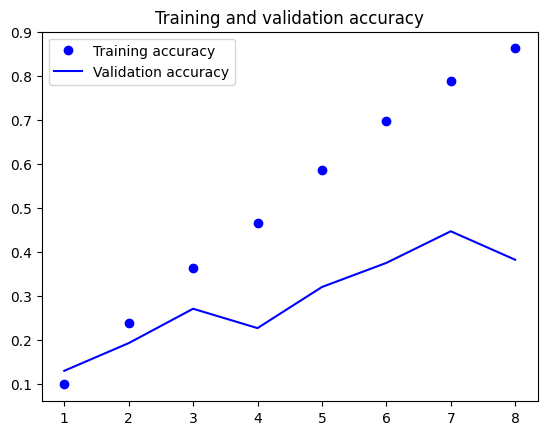

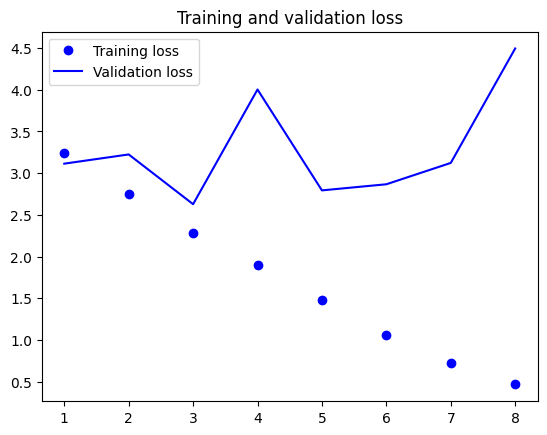

In [17]:
plot_loss_acc_training(history)

### Save the model

In [18]:
save_model_to_drive(model, "model.keras", drive_path="MyDrive/WasteClassifierModels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/WasteClassifierModels/model.keras


### Load the model (if needed)

In [ ]:
model = load_model_from_drive("model.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/WasteClassifierModels/model.keras


### Evaluate the model

In [34]:
evaluate_metrics(model, test_dataset)

Loss:      1.7339
Accuracy:  0.5446
Precision: 0.5557
Recall:    0.5446
F1-Score:  0.5356


{'loss': 1.7339472770690918,
 'accuracy': 0.5445887445887446,
 'precision': 0.5556885647905001,
 'recall': 0.5445887445887446,
 'f1': 0.5355583931462259}

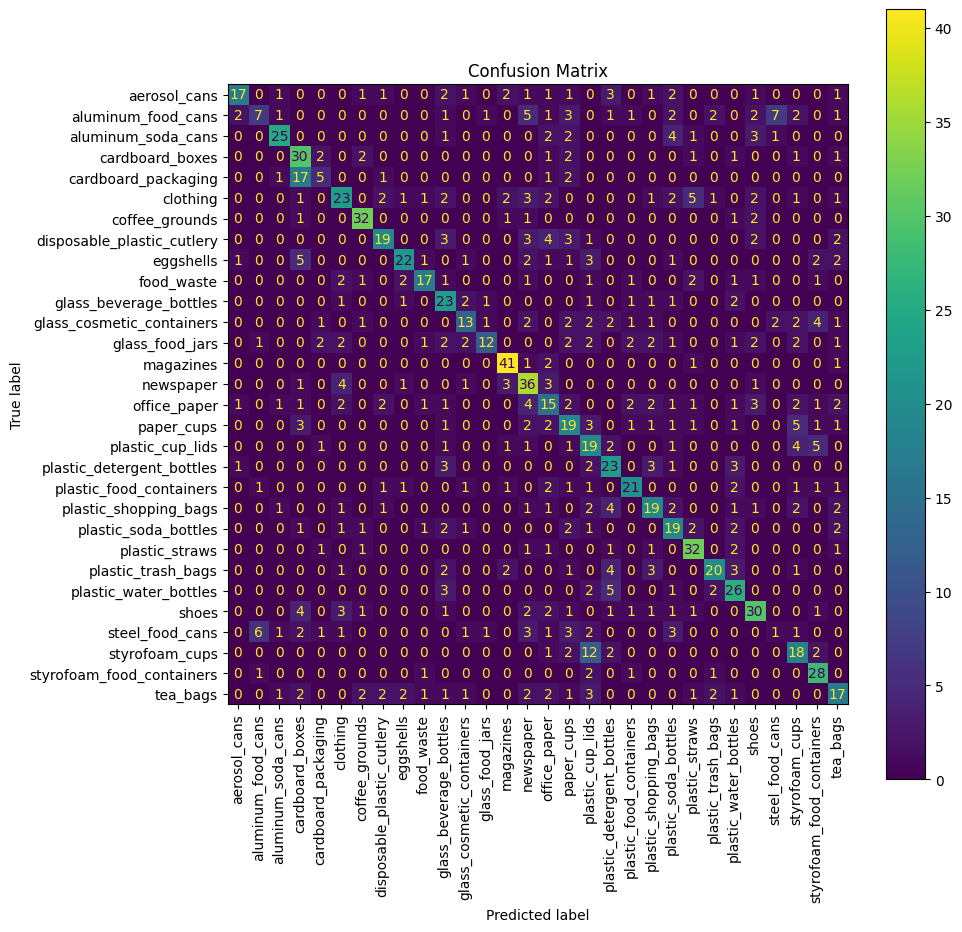

In [36]:
plot_confusion_matrix(model, test_dataset, class_names)

### Plot images with model predictions vs. actual labels

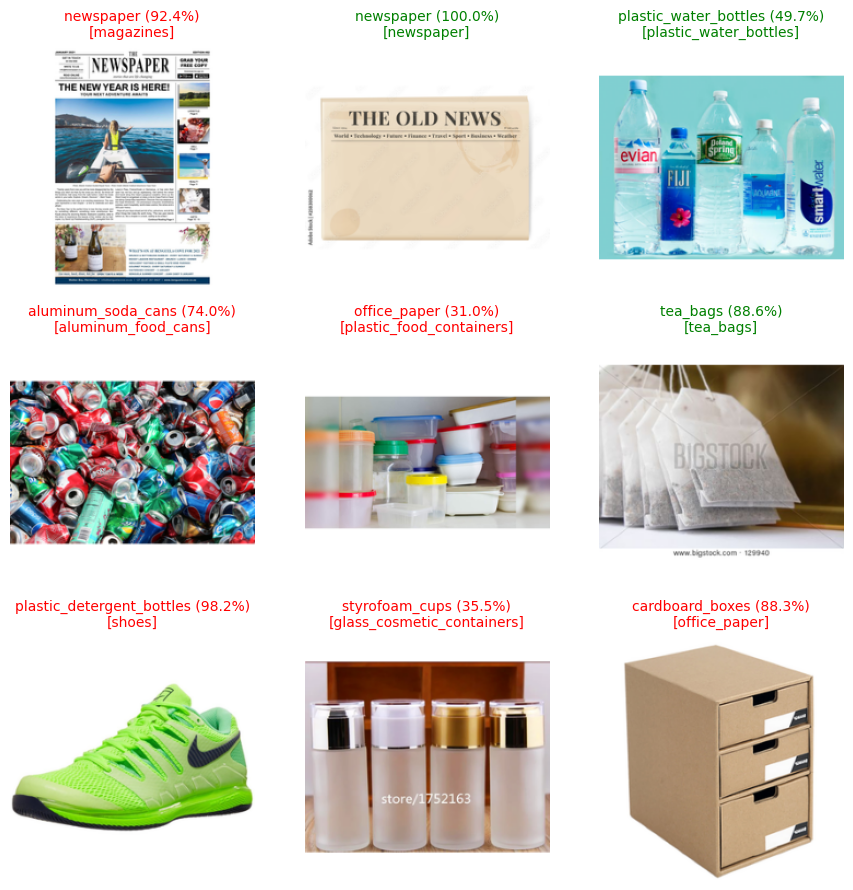

In [37]:
plot_predictions_grid(model, test_dataset, class_names, num_images=9)

## Create data augmented model

In [43]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
     layers.RandomFlip("horizontal"),
     layers.RandomRotation(0.1),
     layers.RandomZoom(0.2),
    ]
)

Add augmentation layer and dropout layers

In [44]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

augmented_model = keras.Model(inputs=inputs, outputs=outputs)

In [45]:
augmented_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │       768,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,526 (6.66 MB)

 Trainable params: 1,746,526 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

In [57]:
# Choose loss function, optimizer, and metrics
augmented_model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

# Callback function to save best model during training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="augmented_model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=40,
        restore_best_weights=True
    ),
]

In [58]:
# Train the model with augmentation
history = augmented_model.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.6047 - loss: 1.3718 - val_accuracy: 0.4429 - val_loss: 2.2426
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.6193 - loss: 1.3087 - val_accuracy: 0.5175 - val_loss: 1.9562
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.6409 - loss: 1.2587 - val_accuracy: 0.4870 - val_loss: 2.4699
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.6480 - loss: 1.2292 - val_accuracy: 0.4501 - val_loss: 2.7158
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.6539 - loss: 1.1973 - val_accuracy: 0.4987 - val_loss: 2.3905
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.6540 - loss: 1.1881 - val_accuracy: 0.4933 - val_loss: 2.2485
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.6709 - loss: 1.1421 - val_accuracy: 0.3890 - val_loss: 3.6784
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.6820 - loss: 

### Display loss curve

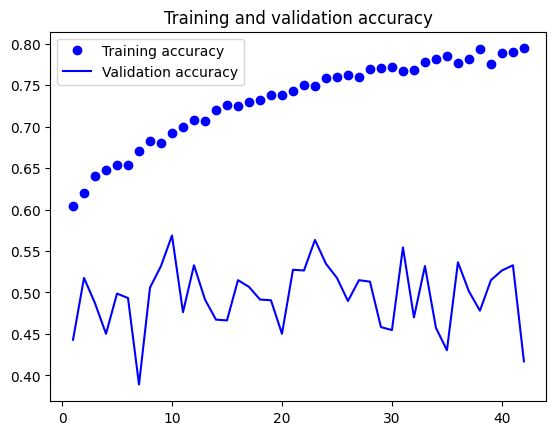

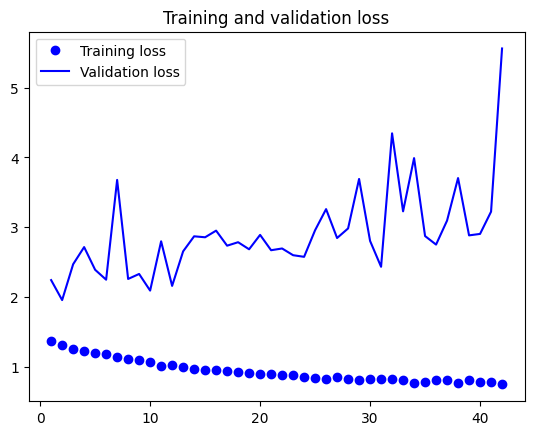

In [59]:
plot_loss_acc_training(history)

### Save the model

In [49]:
save_model_to_drive(augmented_model, "augmented_model.keras", drive_path="MyDrive/WasteClassifierModels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/WasteClassifierModels/augmented_model.keras


### Load the model (if needed)

In [ ]:
augmented_model = load_model_from_drive("augmented_model.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/WasteClassifierModels/augmented_model.keras


### Evaluate the model

In [60]:
evaluate_metrics(augmented_model, test_dataset)

Loss:      1.9332
Accuracy:  0.5411
Precision: 0.5818
Recall:    0.5411
F1-Score:  0.5399


{'loss': 1.9332139492034912,
 'accuracy': 0.5411255411255411,
 'precision': 0.5818183547755992,
 'recall': 0.5411255411255411,
 'f1': 0.5398514165092132}

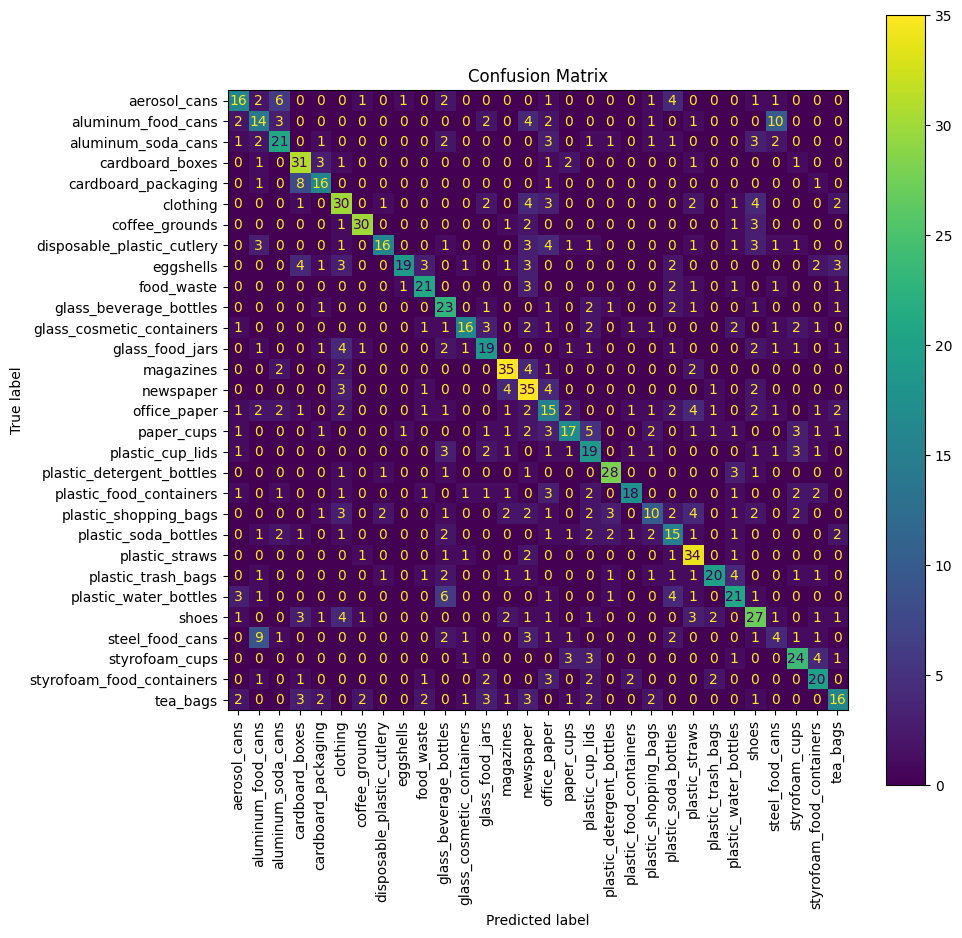

In [56]:
plot_confusion_matrix(augmented_model, test_dataset, class_names)

## Create Model on EfficientNetV2L

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2L
data_augmentation = keras.Sequential(
    [
     layers.RandomFlip("horizontal"),
     layers.RandomRotation(0.1),
     layers.RandomZoom(0.2),
    ]
)

Create EfficientNetV2L

In [ ]:
eff_model = EfficientNetV2L(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(IMG_SIZE + (3,)),
    include_preprocessing=True
)

In [ ]:
#Layers
inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = data_augmentation(inputs)
x = eff_model(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
eff_net_model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
#View Layers
eff_net_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 1280)           │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │        38,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,785,278 (449.32 MB)

 Trainable params: 117,272,702 (447.36 MB)

 Non-trainable params: 512,576 (1.96 MB)

In [ ]:
# Choose loss function, optimizer, and metrics
eff_net_model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

# Callback function to save best model during training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="EfficientNetV2L.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
]

In [ ]:
#Start Training
#I cut batch-size to 8, did not appear to handle 32 well.
history = eff_net_model.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 965s 643ms/step - accuracy: 0.3910 - loss: 2.0928 - val_accuracy: 0.5413 - val_loss: 1.7128
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 936s 624ms/step - accuracy: 0.5468 - loss: 1.5458 - val_accuracy: 0.6160 - val_loss: 1.8259
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 974s 649ms/step - accuracy: 0.6090 - loss: 1.3240 - val_accuracy: 0.6587 - val_loss: 1.2072
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1081s 721ms/step - accuracy: 0.6577 - loss: 1.1508 - val_accuracy: 0.6933 - val_loss: 1.0169
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1033s 688ms/step - accuracy: 0.6848 - loss: 1.0455 - val_accuracy: 0.7087 - val_loss: 0.9734
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1035s 690ms/step - accuracy: 0.7125 - loss: 0.9498 - val_accuracy: 0.7440 - val_loss: 0.8590
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 935s 624ms/step - accuracy: 0.7294 - loss: 0.8842 - val_accuracy: 0.7480 - val_loss: 0.9388
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1063s 708ms/step 

### Save the model

In [ ]:
save_model_to_drive(eff_net_model, "EfficientNetV2L.keras", drive_path="MyDrive/WasteClassifierModels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/WasteClassifierModels/EfficientNetV2L.keras


### Load the model (if needed)

In [ ]:
eff_net_model = load_model_from_drive("EfficientNetV2L.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/WasteClassifierModels/augmented_model.keras


### Evaluate the model

In [ ]:
evaluate_metrics(eff_net_model, test_dataset)

188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 198ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - accuracy: 0.7953 - loss: 0.7478
Loss:      0.7478
Accuracy:  0.7953
Precision: 0.8109
Recall:    0.7953
F1-Score:  0.7973


{'loss': 0.7478092312812805,
 'accuracy': 0.7953333333333333,
 'precision': 0.8108670482400938,
 'recall': 0.7953333333333333,
 'f1': 0.7973214100698932}

Confusion Matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step


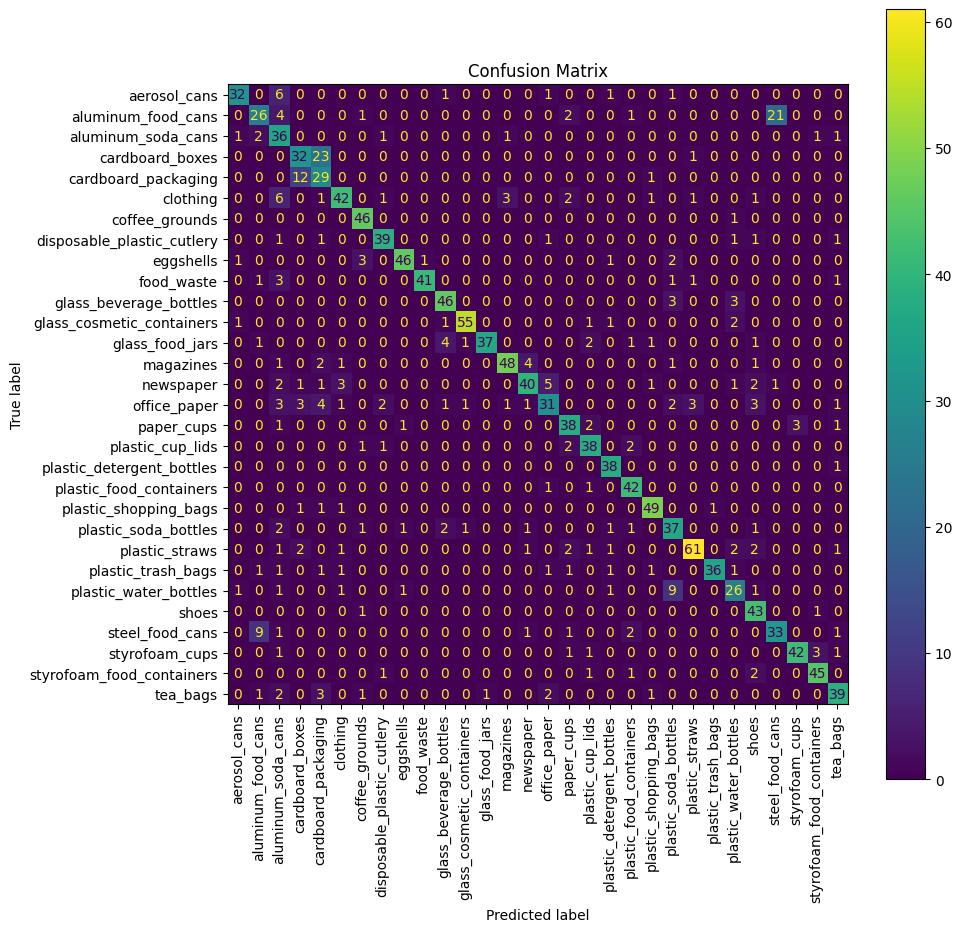

In [ ]:
plot_confusion_matrix(eff_net_model, test_dataset, class_names)

Plot Loss

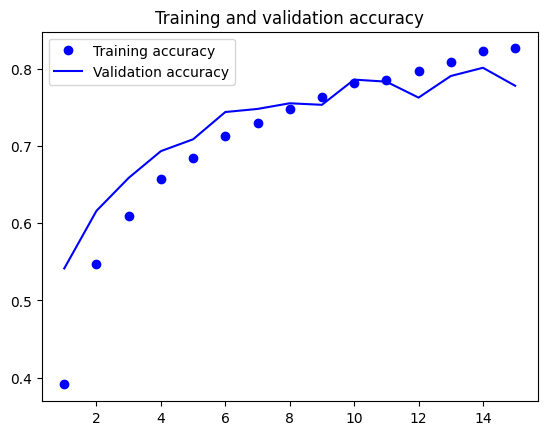

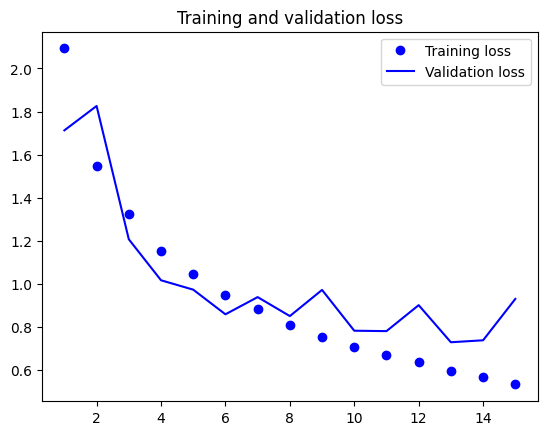

In [ ]:
plot_loss_acc_training(history)

### Plot images with model predictions vs. actual labels

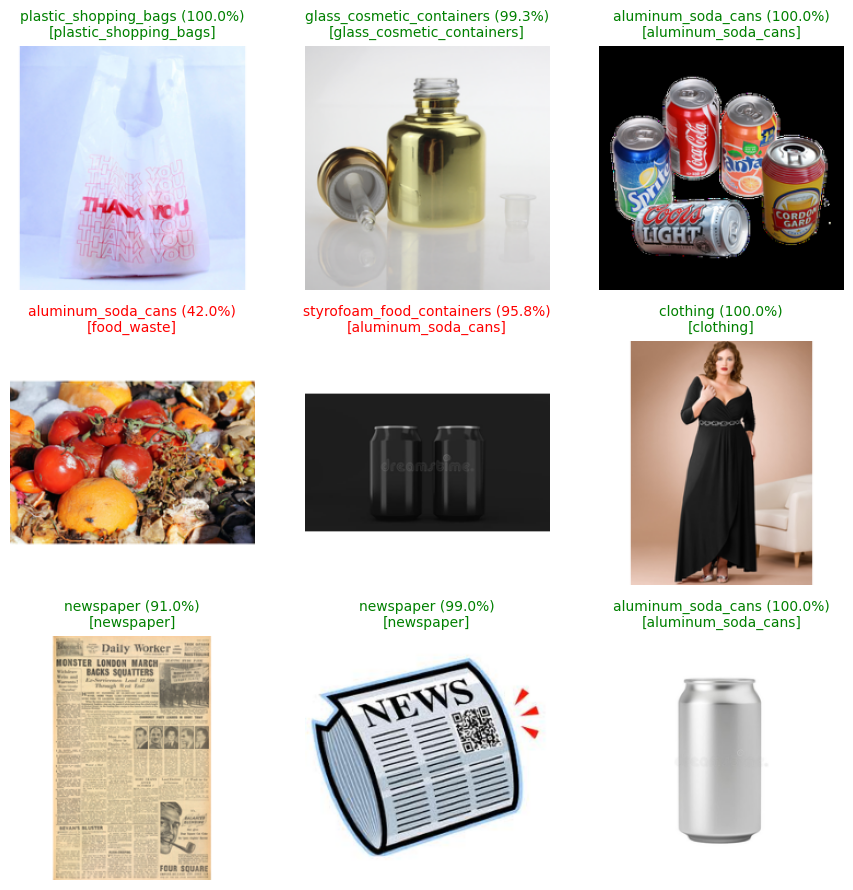

In [ ]:
plot_predictions_grid(eff_net_model, test_dataset, class_names, num_images=9)